# Figure 5 and Figure S12 — gene content across lifestyles

| Panel | Content |
| --- | --- |
| **5a** | UniRef90 gene families per MAG, Westernized vs non-Westernized |
| **5b** | Fold change in gene families against fold change in nGD, per SGB |
| **5c** | PFAM meta-analysis across SGBs, with per-SGB prevalence |
| **S12** | The same PFAMs re-pooled within each phylum |

Figure 4 showed that strains differ between lifestyles. This figure asks what that means for gene
content: non-Westernized MAGs carry more gene families (a), the SGBs whose strains diverge most are
also the ones whose gene counts diverge most (b), and specific protein families are systematically
gained or lost (c).

Panel c is a **meta-analysis across SGBs**. For one PFAM, each SGB with enough MAGs gives a log-odds
ratio for carrying that domain in non-Westernized versus Westernized MAGs; those per-SGB estimates
are pooled with a DerSimonian-Laird random-effects model. That pooling is what the blue diamond is,
and the grey and red dots behind it are the individual SGBs.

Figure S12 is the obvious follow-up: a pooled effect could be driven by one clade. It re-runs the
same pooling separately within each phylum, so a domain that only moves in one of them is visible.

## 0. Setup

Paths follow the `../data` layout. Two inputs are produced outside this notebook and read here:

* `func_meta_analysis.tsv` — the per-SGB and pooled PFAM results. Building it means walking every
  SGB pangenome, mapping UniRef50 clusters to PFAM accessions, and fitting one model per SGB per
  domain; section 3 describes the pipeline and where it lives.
* `pfam_u50_10prev.tsv` — the genome-by-PFAM presence table those models were fitted on, kept here
  because the prevalence panel of 5c is computed directly from it.

In [14]:
import bz2
import re

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu, norm, pearsonr

DATA = '../data'
SGB_DB = f'{DATA}/SGB.Jan21.txt.bz2'
U90_COUNTS = f'{DATA}/nw_counts_u90.tsv'            # UniRef90 families per MAG
DISTANCES = f'{DATA}/nw_distances_final.tsv'        # per-SGB nGD summary (as in Figure 4)
META_ANALYSIS = f'{DATA}/func_meta_analysis.tsv'    # per-SGB and pooled PFAM results
PFAM_NAMES = f'{DATA}/pfam.tsv'                     # accession -> readable name
GENES_OF_INTEREST = f'{DATA}/fig5d_data.tsv'        # the PFAMs the figure shows
PFAM_PRESENCE = f'{DATA}/pfam_u50_10prev.tsv.bz2'       # genomes x PFAM presence/absence

W_COLOR = '#397797'
NW_COLOR = '#d5d53e'
LIFESTYLE_COLORS = {'Westernized': W_COLOR, 'non-Westernized': NW_COLOR}
SGB_TYPE_COLORS = {'kSGB': '#36a949', 'uSGB': '#dd8452'}

EFFECT_COLOR = '#4C72B0'      # pooled estimate
SIGNIF_COLOR = '#C44E52'      # per-SGB estimate, significant
NONSIGNIF_COLOR = '#808080'   # per-SGB estimate, not significant
CI_COLOR = '#C3C3C3'
BUBBLE_NW, BUBBLE_W = '#e6e64c', '#3d86ac'

Q_SGB = 0.2                   # per-SGB q-value drawn as significant in panel 5c
ALPHA_PHYLUM = 0.05           # p-value for a filled bubble in Figure S12
MIN_SGBS_PER_PHYLUM = 3       # SGBs a phylum needs before it is pooled on its own

# The SGB release uses the older phylum names; the figure uses the current ones.
PHYLUM_NAMES = {'Firmicutes': 'Bacillota', 'Bacteroidetes': 'Bacteroidota',
                'Actinobacteria': 'Actinomycetota', 'Proteobacteria': 'Pseudomonadota',
                'Candidatus_Melainabacteria': 'Candidatus Melainabacteriota'}
PHYLUM_ORDER = ['Bacillota', 'Bacteroidota', 'Actinomycetota', 'Pseudomonadota',
                'Candidatus Melainabacteriota']

sns.set_theme(context='paper', style='ticks', font='DejaVu Sans')
mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold',
    'legend.frameon': False, 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

## 1. SGB reference data

One pass over the SGB release gives everything the figure needs about each SGB: whether it has a
reference genome (`kSGB`) or is known only from metagenomes (`uSGB`), and its lineage.

In [2]:
def read_sgb_release(path):
    """{SGB id: (kSGB/uSGB, phylum, family)} from the MetaRefSGB release file."""
    records = {}
    with bz2.open(path, 'rt') as handle:
        for line in handle:
            if line.startswith('GGB'):      # SGB rows come first; stop at the GGB block
                break
            if not line.startswith('SGB'):
                continue
            fields = line.strip().split('\t')
            lineage = {clade[:3]: clade[3:] for clade in fields[9].split('|')}
            records[fields[1]] = (fields[7], lineage.get('p__'), lineage.get('f__'))
    return records


sgb_release = read_sgb_release(SGB_DB)
sgb2known = {sgb: values[0] for sgb, values in sgb_release.items()}
sgb2phylum = {sgb: values[1] for sgb, values in sgb_release.items()}
sgb2family = {sgb: values[2] for sgb, values in sgb_release.items()}

print(f'{len(sgb_release):,} SGBs in the release')
pd.Series(sgb2known).value_counts().to_frame('SGBs')

70,927 SGBs in the release


,SGBs
uSGB,47186
kSGB,23741


## 2. Panel 5a — gene families per MAG

Every MAG assigned to one of the tested SGBs contributes its UniRef90 family count. The comparison
is across MAGs rather than across SGBs, which is why the p-value is so extreme — the point is the
shift in the distribution, not the strength of the evidence.

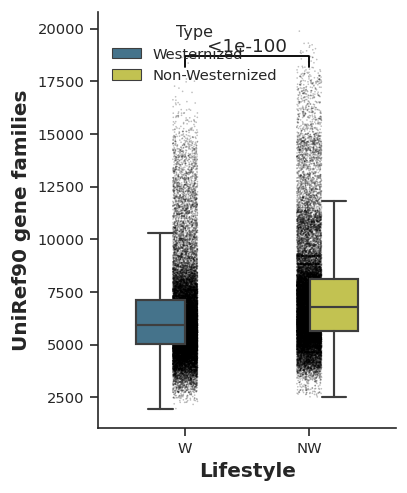

49,896 MAGs, Mann-Whitney p = 0


Type
Westernized        5946.0
Non-Westernized    6792.0
Name: Count, dtype: float64

In [5]:
u90_counts = pd.read_table(U90_COUNTS, index_col=0)
u90_counts['Type'] = pd.Categorical(u90_counts['Type'], ['Westernized', 'Non-Westernized'])

groups = u90_counts.groupby('Type', observed=True)['Count']
u90_pvalue = mannwhitneyu(groups.get_group('Westernized'),
                          groups.get_group('Non-Westernized'), alternative='two-sided').pvalue
u90_label = '<1e-100' if u90_pvalue < 1e-100 else f'{u90_pvalue:.2e}'

fig, ax = plt.subplots(figsize=(3.2, 4.5))
sns.stripplot(data=u90_counts, x='Type', y='Count', color='black', alpha=0.25, size=1,
              zorder=0, rasterized=True, ax=ax)
sns.boxplot(data=u90_counts, x='Type', y='Count', hue='Type',
            palette={'Westernized': W_COLOR, 'Non-Westernized': NW_COLOR},
            fliersize=0, linewidth=1.3, ax=ax)

top = u90_counts['Count'].quantile(0.999)
ax.plot([0, 0, 1, 1], [top * 1.02, top * 1.05, top * 1.05, top * 1.02], lw=1.1, color='black')
ax.text(0.5, top * 1.05, u90_label, ha='center', va='bottom', fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(['W', 'NW'])
ax.set_xlabel('Lifestyle')
ax.set_ylabel('UniRef90 gene families')
sns.despine()
plt.show()

print(f'{len(u90_counts):,} MAGs, Mann-Whitney p = {u90_pvalue:.3g}')
u90_counts.groupby('Type', observed=True)['Count'].median()

## 3. Panel 5b — gene content against strain divergence

Both axes are relative changes between lifestyles, computed per SGB: `(NW - W) / W` for the mean
number of gene families and for the average nGD. If strains that have drifted further apart also
differ more in what they carry, the two should move together — and weakly, they do.

`kSGB` and `uSGB` are shown separately because a reference-genome-backed SGB has a better-defined
pangenome than one assembled only from metagenomes.

In [6]:
distances = pd.read_table(DISTANCES, sep=',', index_col=0)
distances.index = [sgb[6:].replace('_group', '') for sgb in distances.index]   # t__SGBxxxx -> xxxx

mean_counts = (u90_counts.groupby(['SGB', 'Type'], observed=True)['Count'].mean()
               .unstack('Type'))
mean_counts.index = mean_counts.index.astype(str)

shared = [sgb for sgb in distances.index if sgb in mean_counts.index]
fold_changes = pd.DataFrame({
    'FC_nGD': ((distances.loc[shared, 'NW_avg_dist'] - distances.loc[shared, 'W_avg_dist'])
               / distances.loc[shared, 'W_avg_dist']),
    'FC_genes': ((mean_counts.loc[shared, 'Non-Westernized'] - mean_counts.loc[shared, 'Westernized'])
                 / mean_counts.loc[shared, 'Westernized']),
}).dropna()
fold_changes['SGB_type'] = fold_changes.index.map(sgb2known)

r, p = pearsonr(fold_changes['FC_nGD'], fold_changes['FC_genes'])
print(f"{len(fold_changes)} SGBs, Pearson's r = {r:.2f} (p = {p:.2g})")

191 SGBs, Pearson's r = 0.26 (p = 0.00028)


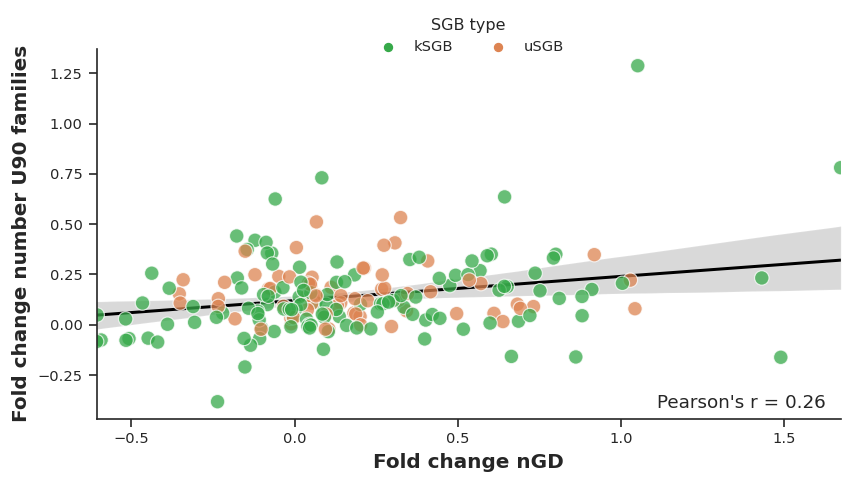

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.regplot(data=fold_changes, x='FC_nGD', y='FC_genes', scatter_kws={'s': 0},
            color='black', line_kws={'zorder': 0}, ax=ax)
sns.scatterplot(data=fold_changes, x='FC_nGD', y='FC_genes', hue='SGB_type',
                palette=SGB_TYPE_COLORS, alpha=0.75, s=75, zorder=1, ax=ax)

ax.set_xlim(fold_changes['FC_nGD'].min(), fold_changes['FC_nGD'].max())
ax.set_xlabel('Fold change nGD')
ax.set_ylabel('Fold change number U90 families')
ax.text(0.98, 0.03, f"Pearson's r = {r:.2f}", transform=ax.transAxes, ha='right', fontsize=11)
ax.legend(title='SGB type', loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2)
sns.despine()
plt.show()

## 4. The PFAM meta-analysis

### 4.1 Where the input comes from

`func_meta_analysis.tsv` is the output of a pipeline that does not run inside a notebook. In outline:

1. For each SGB with at least 40 reconstructed genomes, its MAGs are split by the lifestyle of the
   sample they came from, keeping SGBs with at least 20 MAGs on each side.
2. The SGB pangenome maps each gene to a UniRef50 cluster, and the UniRef50-to-PFAM table turns
   those into PFAM accessions, giving one presence/absence row per genome per domain.
3. Domains present in fewer than 25 genomes are dropped — this is the `_10prev` table read below.
4. Within each SGB, a model of presence against lifestyle gives a log-odds ratio and standard error,
   adjusted for genome completeness and contamination. Those per-SGB columns (`<sgb>_lor`, `_se`,
   `_pval`, `_qval`) are what this notebook reads.

The study-name normalisation that pipeline needs (`ThomasAM_2019_a` to `ThomasAM_2019`, `CM_caritro`
to `FerrettiP_2018`, and so on) is a property of the genome identifiers, not of this figure.

In [10]:
SGB_COLUMN = re.compile(r'^(\d+)_(lor|se|pval|qval)$')

wide = pd.read_table(META_ANALYSIS, decimal=',')
pfam_names = pd.read_table(PFAM_NAMES)
pfid2func = dict(zip(pfam_names['Accession'], pfam_names['Name']))


def to_long(wide):
    """One row per (PFAM, SGB): the per-SGB estimate behind the pooled one."""
    sgbs = sorted({match.group(1) for column in wide.columns
                   if (match := SGB_COLUMN.match(column))})
    frames = []
    for sgb in sgbs:
        columns = {f'{sgb}_{suffix}': suffix for suffix in ('lor', 'se', 'pval', 'qval')
                   if f'{sgb}_{suffix}' in wide.columns}
        if not columns:
            continue
        frames.append(wide[['gene'] + list(columns)].rename(columns=columns).assign(sgb=sgb))
    long = pd.concat(frames, ignore_index=True).dropna(subset=['lor', 'se'])
    long['gene'] = long['gene'].str.split('__').str[-1]
    return long


long_df = to_long(wide)
long_df['description'] = long_df['gene'].map(pfid2func)
long_df['phylum'] = long_df['sgb'].map(sgb2phylum)
long_df['family'] = long_df['sgb'].map(sgb2family)

genes_of_interest = pd.read_table(GENES_OF_INTEREST)['pfam_accession'].tolist()
print(f"{long_df['gene'].nunique():,} PFAMs x {long_df['sgb'].nunique():,} SGBs, "
      f'{len(genes_of_interest)} shown in the figure')
long_df.head()

3,319 PFAMs x 252 SGBs, 40 shown in the figure


,gene,lor,se,pval,qval,sgb,description,phylum,family
3,PF00009,1.380739,0.774608,0.074668,0.401661,10068,Elongation factor Tu GTP binding domain,Proteobacteria,Enterobacteriaceae
4,PF00011,-1.374948,1.244541,0.269253,0.831441,10068,Hsp20/alpha crystallin family,Proteobacteria,Enterobacteriaceae
6,PF00015,-1.416808,0.467522,0.002442,0.043007,10068,Methyl-accepting chemotaxis protein (MCP) sign...,Proteobacteria,Enterobacteriaceae
7,PF00027,0.203333,0.574737,0.723500,0.999994,10068,Cyclic nucleotide-binding domain,Proteobacteria,Enterobacteriaceae
8,PF00037,0.044417,0.628012,0.943616,0.999994,10068,4Fe-4S binding domain,Proteobacteria,Enterobacteriaceae


### 4.2 Pooling

DerSimonian-Laird: the per-SGB estimates are averaged with weights `1 / (se² + tau²)`, where `tau²`
is the between-SGB variance estimated from how much more they disagree than their own standard
errors allow. With `tau² = 0` this is the fixed-effect average; the more the SGBs disagree, the more
the weights even out and the wider the pooled interval.

In [11]:
def dl_meta(lor, se):
    """DerSimonian-Laird random-effects pooling of per-SGB log-odds ratios."""
    lor, se = np.asarray(lor, dtype=float), np.asarray(se, dtype=float)
    k = len(lor)
    if k < 2:
        return dict(lor=lor[0] if k else np.nan, se=se[0] if k else np.nan,
                    pval=np.nan, tau2=np.nan, Q=np.nan, I2=np.nan, k=k)

    fixed_weights = 1 / se ** 2
    fixed_lor = np.sum(fixed_weights * lor) / np.sum(fixed_weights)

    Q = np.sum(fixed_weights * (lor - fixed_lor) ** 2)          # heterogeneity
    C = np.sum(fixed_weights) - np.sum(fixed_weights ** 2) / np.sum(fixed_weights)
    tau2 = max(0, (Q - (k - 1)) / C) if C > 0 else 0.0

    random_weights = 1 / (se ** 2 + tau2)
    pooled = np.sum(random_weights * lor) / np.sum(random_weights)
    pooled_se = np.sqrt(1 / np.sum(random_weights))

    return dict(lor=pooled, se=pooled_se,
                pval=2 * (1 - norm.cdf(abs(pooled / pooled_se))),
                tau2=tau2, Q=Q, I2=max(0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0, k=k)


pooled = pd.DataFrame([dict(gene=gene, **dl_meta(sub['lor'], sub['se']))
                       for gene, sub in long_df[long_df['gene'].isin(genes_of_interest)]
                       .groupby('gene')]).set_index('gene')
pooled['description'] = pooled.index.map(pfid2func)
pooled['ci_lo'] = pooled['lor'] - 1.96 * pooled['se']
pooled['ci_hi'] = pooled['lor'] + 1.96 * pooled['se']
pooled = pooled.sort_values('lor', ascending=False)

pooled[['description', 'lor', 'se', 'pval', 'k', 'I2']].head()

,description,lor,se,pval,k,I2
gene,,,,,,
PF11545,Cell surface heme-binding protein Shp,1.554128,0.484848,0.001349,11,85.315955
PF14107,Domain of unknown function (DUF4280),1.346204,0.358087,0.000170,8,71.704278
PF13031,Protein of unknown function (DUF3892),1.289813,0.334031,0.000113,14,76.267228
PF01874,ATP:dephospho-CoA triphosphoribosyl transferase,0.949684,0.232720,0.000045,13,58.569841
PF16141,"Glycoside hydrolase family 18, BT1044-like",0.826134,0.317376,0.009241,16,70.398977


### 4.3 Prevalence per SGB

The right-hand half of panel 5c. For each PFAM and each SGB, the share of that SGB's MAGs carrying
the domain, separately per lifestyle; the boxplot is then over SGBs. This is the raw quantity the
log-odds ratios are computed from, and it shows what a given pooled effect looks like in practice —
a large odds ratio can come from a domain that is near-universal on one side and merely common on
the other, or from one that is rare on both.

In [15]:
HEADER_ROWS = ['SGB', 'Completeness', 'Contamination', 'Lifestyle']

def pfam_prevalence(path, genes):
    """Prevalence (%) of each PFAM within each SGB, per lifestyle."""
    table = pd.read_table(path, index_col=0, compression="bz2")
    header = table.loc[HEADER_ROWS]
    wanted = [f'gene__{gene}' for gene in genes if f'gene__{gene}' in table.index]

    presence = table.loc[wanted].astype(float).T
    presence.columns = [column.replace('gene__', '') for column in presence.columns]
    presence['SGB'] = header.loc['SGB'].values
    presence['Lifestyle'] = header.loc['Lifestyle'].values

    prevalence = presence.groupby(['SGB', 'Lifestyle']).mean() * 100
    return prevalence.reset_index().melt(id_vars=['SGB', 'Lifestyle'], var_name='gene',
                                         value_name='prevalence')


prevalence = pfam_prevalence(PFAM_PRESENCE, genes_of_interest)
print(f"{prevalence['gene'].nunique()} PFAMs x {prevalence['SGB'].nunique()} SGBs")
prevalence.groupby('Lifestyle')['prevalence'].describe()[['count', 'mean', '50%']]

/tmp/ipykernel_1787417/4100468718.py:5: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,2

40 PFAMs x 252 SGBs


,count,mean,50%
Lifestyle,,,
Westernized,10080.0,6.020869,0.0
non-Westernized,10080.0,6.115548,0.0


### 4.4 Panel 5c

Left: the pooled log-odds ratio as a blue diamond with its 95% interval, and behind it every SGB
that contributed, red where that SGB's own q-value is below 0.2. Right: the prevalence distributions
the estimates came from. Rows are sorted by pooled effect, so non-Westernized-enriched domains are
at the top.

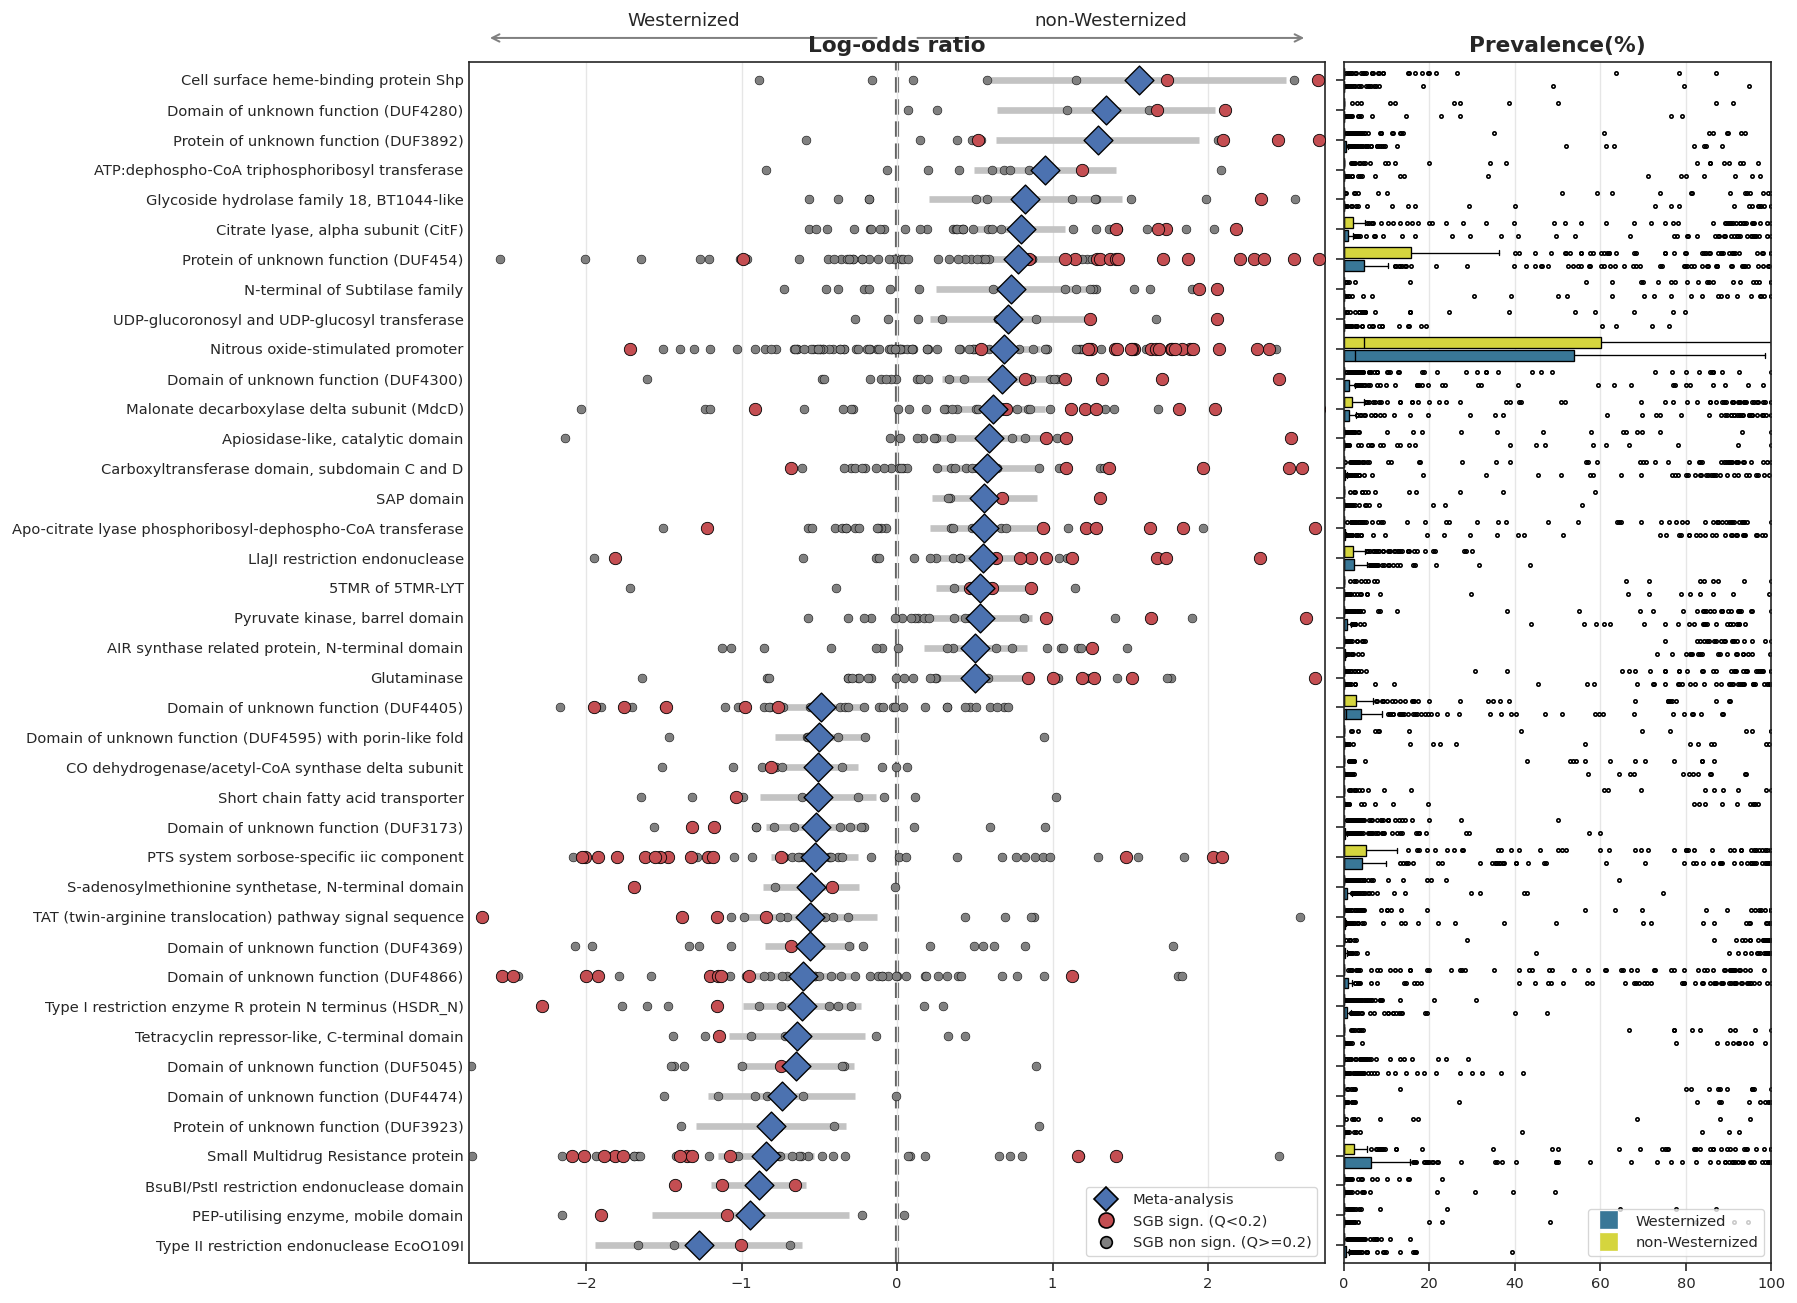

In [17]:
genes_ordered = pooled.index.tolist()
y_positions = np.arange(len(genes_ordered))

fig, (ax, ax_prev) = plt.subplots(1, 2, figsize=(14, 13), sharey=True,
                                  gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.03})

for y, gene in enumerate(genes_ordered):
    row = pooled.loc[gene]
    per_sgb = long_df[long_df['gene'] == gene]
    significant = per_sgb['qval'] < Q_SGB

    ax.scatter(per_sgb.loc[~significant, 'lor'], np.full((~significant).sum(), y),
               s=28, color=NONSIGNIF_COLOR, edgecolors='black', linewidths=0.3, zorder=2)
    ax.scatter(per_sgb.loc[significant, 'lor'], np.full(significant.sum(), y),
               s=55, color=SIGNIF_COLOR, edgecolors='black', linewidths=0.5, zorder=3)
    ax.plot([row['ci_lo'], row['ci_hi']], [y, y], color=CI_COLOR, linewidth=4,
            solid_capstyle='butt', zorder=1)
    ax.scatter(row['lor'], y, marker='D', s=150, color=EFFECT_COLOR,
               edgecolors='black', linewidths=0.8, zorder=4)

    for lifestyle, offset in (('Westernized', 0.22), ('non-Westernized', -0.22)):
        values = prevalence[(prevalence['gene'] == gene)
                            & (prevalence['Lifestyle'] == lifestyle)]['prevalence'].dropna()
        if values.empty:
            continue
        ax_prev.boxplot(values, positions=[y + offset], vert=False, widths=0.36,
                        patch_artist=True, manage_ticks=False,
                        boxprops=dict(facecolor=LIFESTYLE_COLORS[lifestyle], linewidth=0.8),
                        medianprops=dict(color='black', linewidth=0.8),
                        whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                        flierprops=dict(marker='o', markersize=2, markerfacecolor='none'))

ax.axvline(0, color='#636363', linestyle='--', linewidth=2.5, zorder=0)
ax.set_ylim(-0.6, len(genes_ordered) - 0.4)
ax.invert_yaxis()
ax.set_yticks(y_positions)
ax.set_yticklabels(pooled['description'])
ax.tick_params(axis='y', length=0)
ax.set_title('Log-odds ratio')
ax.grid(axis='x', color='#e6e6e6')

ax.annotate('', xy=(0.02, 1.02), xytext=(0.48, 1.02), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='gray', linewidth=1.2))
ax.annotate('', xy=(0.98, 1.02), xytext=(0.52, 1.02), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='gray', linewidth=1.2))
ax.text(0.25, 1.03, 'Westernized', transform=ax.transAxes, ha='center', fontsize=11)
ax.text(0.75, 1.03, 'non-Westernized', transform=ax.transAxes, ha='center', fontsize=11)

ax_prev.set_title('Prevalence(%)')
ax_prev.set_xlim(0, 100)
ax_prev.grid(axis='x', color='#e6e6e6')

ax.legend(handles=[
    Line2D([], [], linestyle='', marker='D', color=EFFECT_COLOR, markeredgecolor='black',
           markersize=10, label='Meta-analysis'),
    Line2D([], [], linestyle='', marker='o', color=SIGNIF_COLOR, markeredgecolor='black',
           markersize=9, label=f'SGB sign. (Q<{Q_SGB})'),
    Line2D([], [], linestyle='', marker='o', color=NONSIGNIF_COLOR, markeredgecolor='black',
           markersize=7, label=f'SGB non sign. (Q>={Q_SGB})'),
], loc='lower right', frameon=True)
ax_prev.legend(handles=[Line2D([], [], marker='s', linestyle='', markersize=10,
                               color=color, label=lifestyle)
                        for lifestyle, color in LIFESTYLE_COLORS.items()],
               loc='lower right', frameon=True)

ax.set_xlim(-2.75, 2.75)
plt.show()

## 5. Figure S12 — the same domains, pooled within each phylum

The pooled effect in panel 5c mixes SGBs from every phylum. Here the same per-SGB estimates are
pooled again inside each phylum that contributed at least three SGBs for that domain, so a signal
carried by one clade alone separates from one that holds across the tree.

Bubble colour is the direction, fill opacity and the black edge mark significance, and size is the
number of SGBs behind the estimate — which is the thing to read first, since a phylum column with
three SGBs says much less than the overall column with hundreds.

In [18]:
def pool_by_phylum(long_df, genes, min_sgbs=MIN_SGBS_PER_PHYLUM):
    """Pooled estimate per gene: overall, then within each sufficiently represented phylum."""
    rows = []
    for gene in genes:
        gene_rows = long_df[long_df['gene'] == gene]
        rows.append(dict(gene=gene, stratum='overall', **dl_meta(gene_rows['lor'], gene_rows['se'])))
        for phylum, group in gene_rows.groupby('phylum'):
            if len(group) >= min_sgbs:
                rows.append(dict(gene=gene, stratum=PHYLUM_NAMES.get(phylum, phylum),
                                 **dl_meta(group['lor'], group['se'])))
    return pd.DataFrame(rows)


stratified = pool_by_phylum(long_df, genes_of_interest)

strata_order = ['overall'] + [phylum for phylum in PHYLUM_ORDER
                              if phylum in set(stratified['stratum'])]
pivot_lor = stratified.pivot(index='gene', columns='stratum', values='lor').reindex(
    columns=strata_order).loc[genes_ordered[::-1]]
pivot_pval = stratified.pivot(index='gene', columns='stratum', values='pval').reindex(
    columns=strata_order).loc[pivot_lor.index]
pivot_k = stratified.pivot(index='gene', columns='stratum', values='k').reindex(
    columns=strata_order).loc[pivot_lor.index]

print(f'{len(strata_order)} columns: {strata_order}')
pivot_k.describe().T[['mean', 'max']]

6 columns: ['overall', 'Bacillota', 'Bacteroidota', 'Actinomycetota', 'Pseudomonadota', 'Candidatus Melainabacteriota']


,mean,max
stratum,,
overall,23.825,118.0
Bacillota,19.500,80.0
Bacteroidota,11.350,26.0
Actinomycetota,4.600,6.0
Pseudomonadota,3.750,6.0
Candidatus Melainabacteriota,3.000,3.0


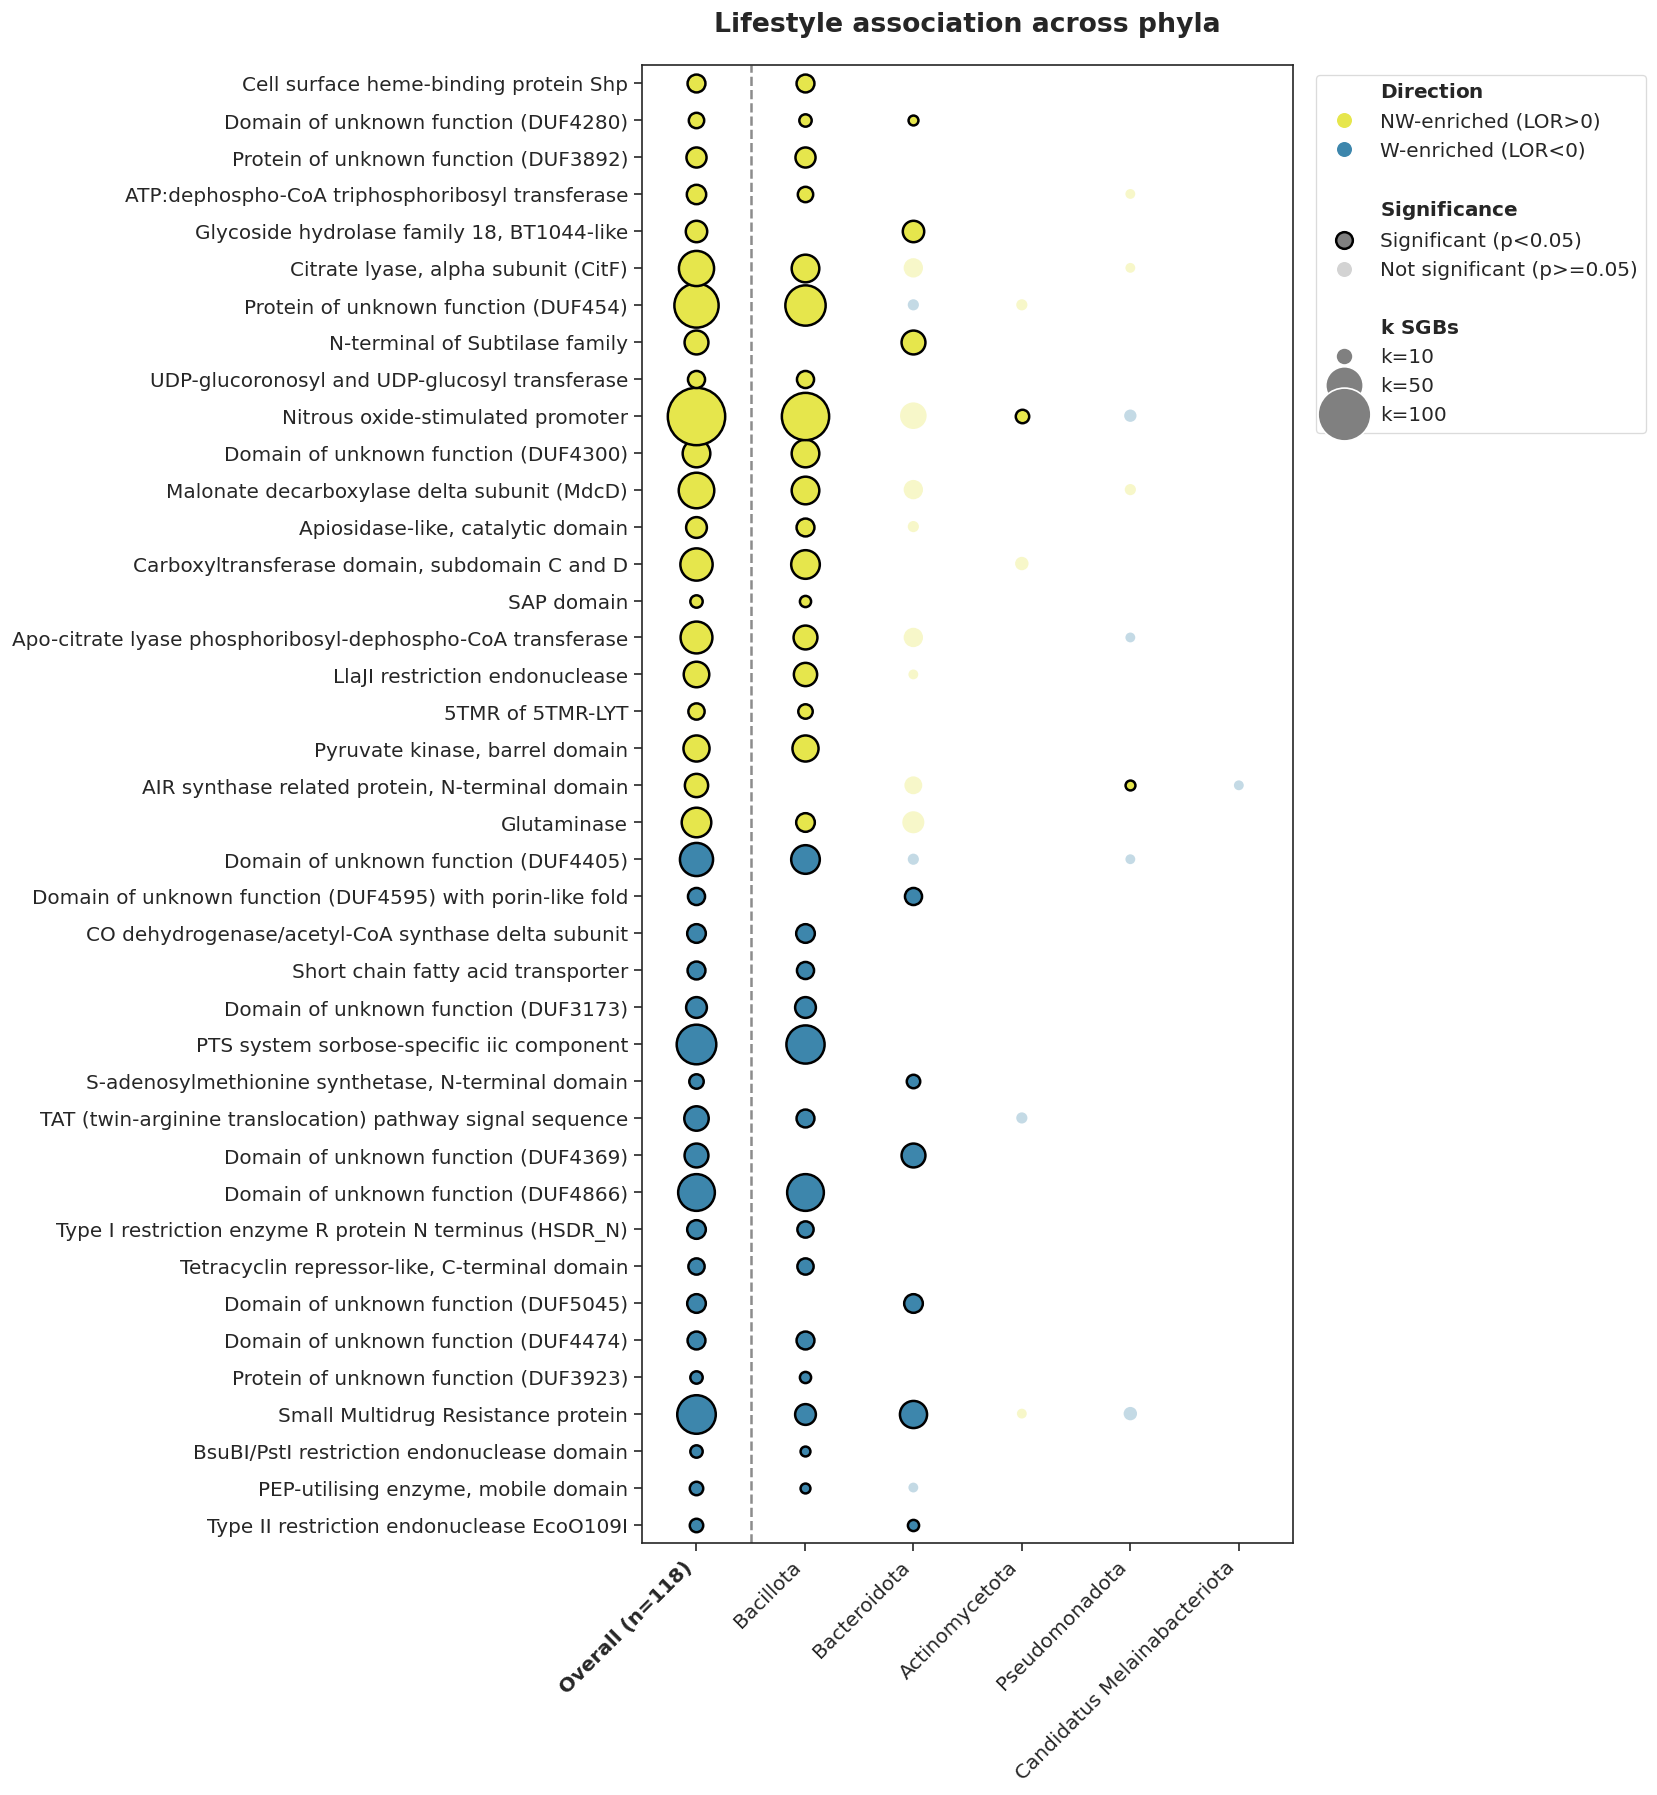

In [19]:
def bubble_size(k):
    return 5 + 10 * (k if not np.isnan(k) else 1)


n_overall = int(pivot_k['overall'].max())
column_labels = [f'Overall (n={n_overall})'] + strata_order[1:]

fig, ax = plt.subplots(figsize=(7, 16))

for i, gene in enumerate(pivot_lor.index):
    for j, stratum in enumerate(strata_order):
        lor, pvalue, k = pivot_lor.loc[gene, stratum], pivot_pval.loc[gene, stratum], pivot_k.loc[gene, stratum]
        if np.isnan(lor):
            continue
        significant = pvalue < ALPHA_PHYLUM
        ax.scatter(j, i, s=bubble_size(k), color=BUBBLE_NW if lor > 0 else BUBBLE_W,
                   alpha=1.0 if significant else 0.3,
                   edgecolor='black' if significant else 'none', linewidth=1.5)

ax.axvline(0.5, color='#8c8c8c', linestyle='--', linewidth=1.5, zorder=0)
ax.set_xticks(range(len(strata_order)))
ax.set_xticklabels(column_labels, rotation=45, ha='right', fontsize=12)
ax.get_xticklabels()[0].set_fontweight('bold')
ax.set_yticks(range(len(pivot_lor)))
ax.set_yticklabels([pfid2func.get(gene, gene) for gene in pivot_lor.index], fontsize=12)
ax.set_xlim(-0.5, len(strata_order) - 0.5)
ax.set_ylim(-0.5, len(pivot_lor) - 0.5)
ax.set_title('Lifestyle association across phyla', fontsize=16, pad=20)
ax.grid(False)

def swatch(color, **kwargs):
    return Line2D([], [], marker='o', color='w', markerfacecolor=color, linestyle='', **kwargs)


legend_elements = (
    [Line2D([], [], color='none', label='$\\bf{Direction}$'),
     swatch(BUBBLE_NW, markersize=10, label='NW-enriched (LOR>0)'),
     swatch(BUBBLE_W, markersize=10, label='W-enriched (LOR<0)'),
     Line2D([], [], color='none', label=''),
     Line2D([], [], color='none', label='$\\bf{Significance}$'),
     swatch('gray', markersize=10, markeredgecolor='black', markeredgewidth=1.5,
            label=f'Significant (p<{ALPHA_PHYLUM})'),
     swatch('lightgray', markersize=10, label=f'Not significant (p>={ALPHA_PHYLUM})'),
     Line2D([], [], color='none', label=''),
     Line2D([], [], color='none', label='$\\bf{k\\ SGBs}$')]
    + [swatch('gray', markersize=np.sqrt(bubble_size(k)), label=f'k={k}') for k in (10, 50, 100)])

ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=True, facecolor='white', edgecolor='#d3d3d3', fontsize=12)
plt.show()